# 14 — Multi-Panel Publication Figures

Each figure cell writes its layout directly in matplotlib. Shared chrome
(fonts, palette, helpers, save) is imported from
`gtex_biomarkers.figure_builder` so the cells stay focused on layout
decisions and you can edit the numbers in place.

Output: `output/figures/figure_{1..5}.pdf` + `.png` (600 dpi).

1. **Figure 1** — Pan-tissue prediction from whole-blood expression.
2. **Figure 2** — Expression signal beyond donor variables.
3. **Figure 3** — PC-based blood signatures for nine pathologies.
4. **Figure 4** — PC-derived gene rankings and pathway enrichment.
5. **Figure 5** — External validation and candidate biomarkers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.stats import spearmanr

from gtex_biomarkers.config import Config
from gtex_biomarkers.figure_builder import (
    apply_style, save_fig, panel_letter, thin_spines, short_pair, load_data,
    CORAL, STEEL, SAGE, GOLD, SLATE, GRAY, GRAY_LT,
    CMAP_AUC, CMAP_NES, CMAP_RANK,
)

Config.ensure_dirs()
apply_style()
data = load_data()

# Unpack into module-level names so each figure cell can use them directly
lr         = data["lr"]
rf         = data["rf"]
three      = data["three"]
three_top  = data["three_top"]
conf_imp   = data["conf_imp"]
pc_auc     = data["pc_auc"]
pc_auc_top = data["pc_auc_top"]
pc_imp     = data["pc_imp"]
pc_vs_rf   = data["pc_vs_rf"]
gsea       = data["gsea"]
pca_cv     = data["pca_cv"]

print(f"loaded: LR={len(lr)}  RF={len(rf)}  three={len(three)} (top15={len(three_top)})  "
      f"PC={len(pc_auc)} (top9={len(pc_auc_top)})  GSEA={len(gsea)}  "
      f"PCA_PC100={pca_cv.loc[pca_cv['pc']==100,'cum_var'].iloc[0]*100:.1f}%")

loaded: LR=59  RF=59  three=59 (top15=14)  PC=59 (top9=4)  GSEA=333  PCA_PC100=84.3%


# Figure 1 — Cohort Overview and Clinical co-variate Structure

**A** *Study-design schematic — added externally in BioRender.*
**B** Per-pair class balance: stacked horizontal bars (blue = positive, red = negative) for every screened tissue–pathology pair, grouped by tissue and sorted by % positive descending.
**C** PC1 vs PC2 scatter of the 803 whole-blood donors (top-20K variance-filtered + scaled
PCA), colored by each of the five clinical co-variates (TRISCHD, AGE, SEX, RACE, DTHHRDY).

  saved figure_1.pdf  (1255 KB)


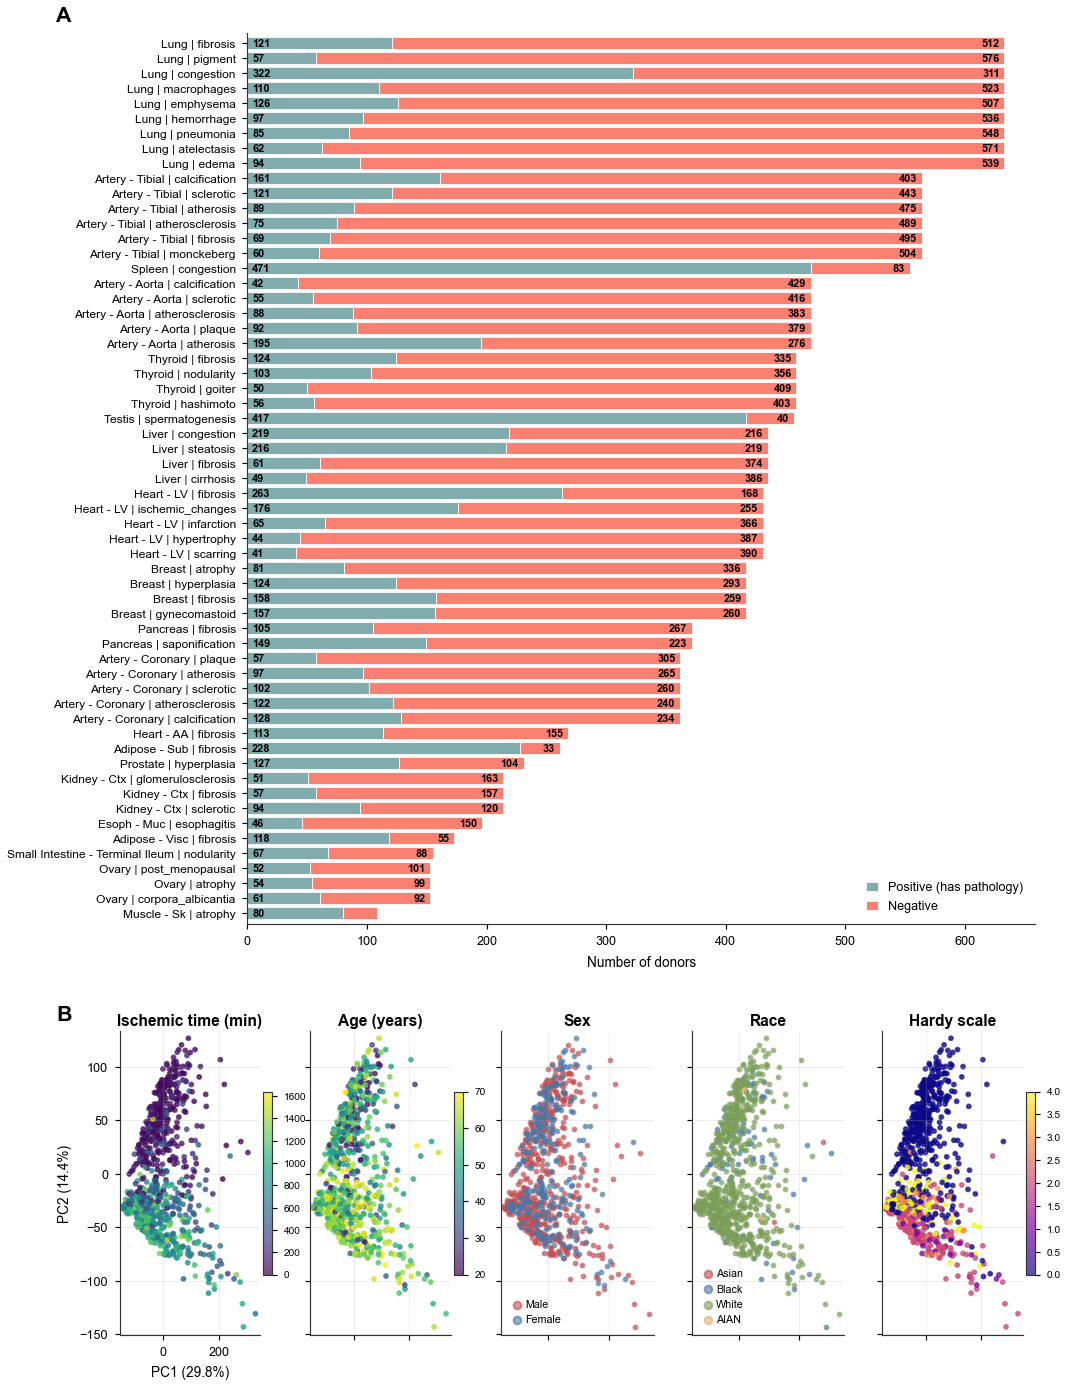

In [2]:
# --- Load Fig 1 data ---------------------------------------------------------
balance = pd.read_csv(Config.TABLES_DIR / "pair_class_balance.csv")
ds      = pd.read_csv(Config.TABLES_DIR / "pca_donor_scores_wb20k.csv", index_col=0)
ve      = pd.read_csv(Config.TABLES_DIR / "pca_explained_variance_top10.csv")["var_ratio"].values

SEX_LABEL  = {1: "Male", 2: "Female"}
RACE_LABEL = {1: "Asian", 2: "Black", 3: "White", 4: "AIAN"}

# --- Layout ------------------------------------------------------------------
# Two GridSpecs share the same vertical geometry but use different left margins
# so panel B's y-axis label flushes with panel A's longest tick label.
fig = plt.figure(figsize=(7.6, 10.0))
COMMON = dict(figure=fig, height_ratios=[5.0, 1.7], hspace=0.18,
              top=0.98, bottom=0.05, right=0.96)
gsA = GridSpec(2, 1, **COMMON, left=0.22)
gsB = GridSpec(2, 1, **COMMON, left=0.10)

# ============================================================== A class balance
axA = fig.add_subplot(gsA[0])

ordered = (balance
           .assign(label=lambda d: [short_pair(t, p)
                                    for t, p in zip(d["tissue"], d["pathology"])])
           .sort_values("n_total", ascending=False)
           .reset_index(drop=True))

y = np.arange(len(ordered))[::-1]   # largest cohort at top

axA.barh(y, ordered["n_pos"], color="#639A9BD0",
         edgecolor="white", lw=0.4, label="Positive (has pathology)")
axA.barh(y, ordered["n_neg"], left=ordered["n_pos"], color="salmon",
         edgecolor="white", lw=0.4, label="Negative")

# Positive count at left edge of its segment; negative count at right edge of bar.
PAD = 4
for yi, p, n, tot in zip(y, ordered["n_pos"], ordered["n_neg"], ordered["n_total"]):
    if p > 28:
        axA.text(PAD, yi, f"{int(p)}", ha="left", va="center",
                 fontsize=5.6, color="black", fontweight="bold")
    if n > 28:
        axA.text(tot - PAD, yi, f"{int(n)}", ha="right", va="center",
                 fontsize=5.6, color="black", fontweight="bold")

axA.set_yticks(y)
axA.set_yticklabels(ordered["label"], fontsize=6.2)
axA.set_ylim(-0.7, len(ordered) - 0.3)
axA.set_xlabel("Number of donors")
axA.set_xlim(0, ordered["n_total"].max() * 1.04)
axA.legend(loc="lower right", fontsize=6.5, frameon=False, handlelength=1.0)
thin_spines(axA)

# ============================================================== B 5x scatters
gsB_inner = gsB[1].subgridspec(1, 5, wspace=0.25)

x_lo, x_hi = ds["PC1"].min() * 1.05, ds["PC1"].max() * 1.05
y_lo, y_hi = ds["PC2"].min() * 1.05, ds["PC2"].max() * 1.05

specs = [
    ("TRISCHD", "Ischemic time (min)", "viridis", False, None),
    ("AGE",     "Age (years)",         "viridis", False, None),
    ("SEX",     "Sex",                  None,     True,  SEX_LABEL),
    ("RACE",    "Race",                 None,     True,  RACE_LABEL),
    ("DTHHRDY", "Hardy scale",          "plasma", False, None),
]

axB_list = []
for i, (col, title, cmap, is_cat, label_map) in enumerate(specs):
    if i == 0:
        ax = fig.add_subplot(gsB_inner[0, i])
    else:
        ax = fig.add_subplot(gsB_inner[0, i], sharex=axB_list[0], sharey=axB_list[0])

    if is_cat:
        cats = sorted(ds[col].dropna().unique())
        palette = [CORAL, STEEL, SAGE, GOLD, SLATE, GRAY]
        for j, v in enumerate(cats):
            sub = ds[ds[col] == v]
            lab = (label_map.get(int(v), int(v)) if label_map else f"{v:g}")
            ax.scatter(sub["PC1"], sub["PC2"], s=4, alpha=0.6,
                       color=palette[j % len(palette)], label=str(lab),
                       rasterized=True)
        ax.legend(fontsize=5.5, frameon=False, loc="best",
                  handletextpad=0.2, markerscale=2)
    else:
        sc = ax.scatter(ds["PC1"], ds["PC2"], s=4, alpha=0.7,
                        c=ds[col], cmap=cmap, rasterized=True)
        cb = plt.colorbar(sc, ax=ax, fraction=0.06, pad=0.02)
        cb.ax.tick_params(labelsize=5.2)

    ax.set_title(title, fontsize=8, pad=3)
    ax.set_xlim(x_lo, x_hi); ax.set_ylim(y_lo, y_hi)
    ax.grid(True, alpha=0.3, lw=0.4)
    thin_spines(ax)

    if i == 0:
        ax.set_xlabel(f"PC1 ({ve[0]*100:.1f}%)", fontsize=7)
        ax.set_ylabel(f"PC2 ({ve[1]*100:.1f}%)", fontsize=7)
    else:
        plt.setp(ax.get_xticklabels(), visible=False)
        plt.setp(ax.get_yticklabels(), visible=False)
    axB_list.append(ax)

# Panel letters in a vertical line at the leftmost figure margin.
LETTER_X = 0.04
fig.text(LETTER_X, axA.get_position().y1 + 0.005, "A",
         fontsize=11, fontweight="bold", va="bottom", ha="left")
fig.text(LETTER_X, axB_list[0].get_position().y1 + 0.005, "B",
         fontsize=11, fontweight="bold", va="bottom", ha="left")

save_fig(fig, "figure_1.pdf"); plt.show()

# Figure 2 — Modeling: Liver | Cirrhosis Case Study and Qualifying Pairs

**A** Top 10 PCs (Liver | cirrhosis) ranked by univariate 5-fold CV AUC (mean ± SD).
**B** Liver | cirrhosis AUC across 4 expression-driven model variants
(LR raw, RF raw, PC-LR, PC-RF), 5-fold CV mean ± SD.
**C** PC-qualifying pairs (`auc_pc_conf ≥ Config.AUC_THRESH` AND `delta_pc ≥ Config.DELTA_THRESH`): paired bars of clinical co-variate-only AUC vs PC + co-variates AUC.
**D** Same qualifying pairs in the same row order as C: ΔAUC (PC + co-variates − co-variates only) lollipop.

The full screened-pair model comparison boxplot is moved to Supplementary Figure S1 (see cell at the end of this notebook).

  saved figure_2.pdf  (39 KB)


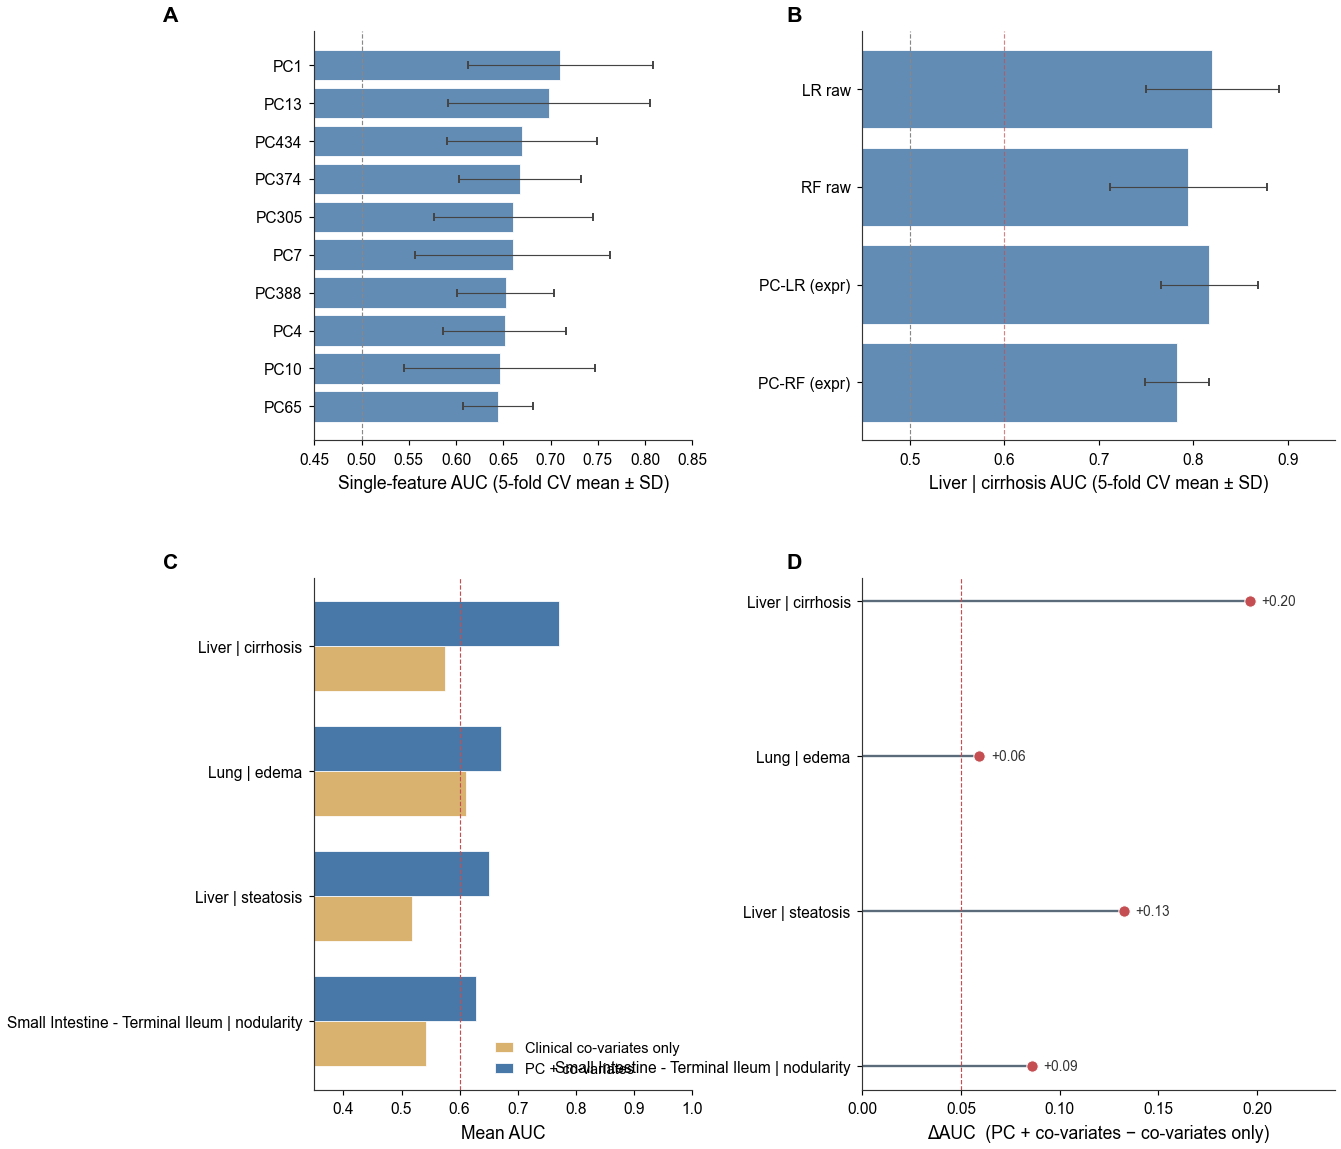

In [3]:
# --- Load Fig 2 data ---------------------------------------------------------
uv_df    = pd.read_csv(Config.TABLES_DIR / "liver_cirrhosis_pc_univariate_auc.csv")
six_mod  = pd.read_csv(Config.TABLES_DIR / "liver_cirrhosis_six_model_auc.csv")
pc_rf    = pd.read_csv(Config.TABLES_DIR / "pc_auc_results.csv")

# Panel B: drop the two co-variate-augmented variants — show only expression-driven models.
four_mod = six_mod[~six_mod["model"].str.contains(r"\+co-vars")].reset_index(drop=True)

# PC-qualifying pairs (auc_pc_conf >= Config.AUC_THRESH AND delta_pc >= Config.DELTA_THRESH)
qualifying = (pc_rf[(pc_rf["auc_pc_conf"] >= Config.AUC_THRESH) & (pc_rf["delta_pc"] >= Config.DELTA_THRESH)]
              .assign(label=lambda d: [short_pair(t, c)
                                        for t, c in zip(d["tissue"], d["category"])])
              .sort_values("auc_pc_conf", ascending=False)
              .reset_index(drop=True))

# --- Layout ------------------------------------------------------------------
fig = plt.figure(figsize=(9.0, 8.4))
gs = GridSpec(2, 2, figure=fig,
              height_ratios=[1.0, 1.25], width_ratios=[1.0, 1.25],
              hspace=0.30, wspace=0.40,
              left=0.16, right=0.97, top=0.97, bottom=0.07)

LABEL_FS = 9
TICK_FS  = 8
LEG_FS   = 7.5

# ============================================================== A top 10 PCs
axA = fig.add_subplot(gs[0, 0])
top10 = uv_df.head(10).iloc[::-1].reset_index(drop=True)
y = np.arange(len(top10))
axA.barh(y, top10["mean_auc"], xerr=top10["std_auc"],
         color=STEEL, alpha=0.85, edgecolor="white", lw=0.5,
         error_kw=dict(lw=0.6, capsize=2, ecolor="#444"))
axA.axvline(0.5, color=GRAY, ls="--", lw=0.6)
axA.set_yticks(y)
axA.set_yticklabels([f"PC{int(p)}" for p in top10["pc"]], fontsize=TICK_FS)
axA.tick_params(axis="x", labelsize=TICK_FS)
axA.set_xlabel("Single-feature AUC (5-fold CV mean ± SD)", fontsize=LABEL_FS)
axA.set_xlim(0.45, max(0.85, (top10["mean_auc"] + top10["std_auc"]).max() * 1.02))
thin_spines(axA)

# ============================================================== B Liver|cirrhosis 4-model
axB = fig.add_subplot(gs[0, 1])
fm = four_mod.iloc[::-1].reset_index(drop=True)   # reverse so first row at top
y_b = np.arange(len(fm))
axB.barh(y_b, fm["mean_auc"], xerr=fm["std_auc"],
         color=STEEL, alpha=0.85, edgecolor="white", lw=0.5,
         error_kw=dict(lw=0.6, capsize=2, ecolor="#444"))
axB.axvline(0.5, color=GRAY, ls="--", lw=0.6)
axB.axvline(0.60, color=CORAL, ls="--", lw=0.6, alpha=0.7)
axB.set_yticks(y_b)
axB.set_yticklabels(fm["model"], fontsize=TICK_FS)
axB.tick_params(axis="x", labelsize=TICK_FS)
axB.set_xlabel("Liver | cirrhosis AUC (5-fold CV mean ± SD)", fontsize=LABEL_FS)
axB.set_xlim(0.45, max(0.95, (fm["mean_auc"] + fm["std_auc"]).max() * 1.02))
thin_spines(axB)

# ============================================================== C qualifying pairs — paired bars
axC = fig.add_subplot(gs[1, 0])
y_pos = np.arange(len(qualifying))[::-1]
h = 0.36
axC.barh(y_pos - h/2, qualifying["auc_conf"], h, color=GOLD,
         edgecolor="white", lw=0.4, label="Clinical co-variates only")
axC.barh(y_pos + h/2, qualifying["auc_pc_conf"], h, color=STEEL,
         edgecolor="white", lw=0.4, label="PC + co-variates")
axC.axvline(0.60, color=CORAL, ls="--", lw=0.6)
axC.set_yticks(y_pos)
axC.set_yticklabels(qualifying["label"], fontsize=TICK_FS)
axC.tick_params(axis="x", labelsize=TICK_FS)
axC.set_xlim(0.35, 1.0)
axC.set_xlabel("Mean AUC", fontsize=LABEL_FS)
axC.legend(loc="lower right", fontsize=LEG_FS, frameon=False, handlelength=1.2)
thin_spines(axC)

# ============================================================== D qualifying pairs — Δ lollipop
axD = fig.add_subplot(gs[1, 1])
axD.hlines(y_pos, 0, qualifying["delta_pc"], color=SLATE, lw=1.2)
axD.scatter(qualifying["delta_pc"], y_pos, s=34, color=CORAL,
            edgecolor="white", linewidth=0.5, zorder=3)
for yi, v in zip(y_pos, qualifying["delta_pc"]):
    axD.text(v + 0.006, yi, f"+{v:.2f}", va="center",
             fontsize=7.0, color="#333")
axD.axvline(0, color="black", lw=0.5)
axD.axvline(0.05, color=CORAL, ls="--", lw=0.6)
axD.set_yticks(y_pos)
axD.set_yticklabels(qualifying["label"], fontsize=TICK_FS)
axD.tick_params(axis="x", labelsize=TICK_FS)
axD.set_xlim(0, qualifying["delta_pc"].max() * 1.22)
axD.set_xlabel("ΔAUC  (PC + co-variates − co-variates only)", fontsize=LABEL_FS)
thin_spines(axD)

# Panel letters
LETTER_X = 0.04
fig.text(LETTER_X, axA.get_position().y1 + 0.005, "A",
         fontsize=11, fontweight="bold", va="bottom", ha="left")
fig.text(LETTER_X, axC.get_position().y1 + 0.005, "C",
         fontsize=11, fontweight="bold", va="bottom", ha="left")
fig.text(axB.get_position().x0 - 0.06, axB.get_position().y1 + 0.005, "B",
         fontsize=11, fontweight="bold", va="bottom", ha="left")
fig.text(axD.get_position().x0 - 0.06, axD.get_position().y1 + 0.005, "D",
         fontsize=11, fontweight="bold", va="bottom", ha="left")

save_fig(fig, "figure_2.pdf"); plt.show()

# Figure 3 — Liver | Cirrhosis Case Study: From PCs to Genes to Pathways

**A** Top 10 principal components by mean Gini importance from the PC-RF model
on Liver | cirrhosis (5-fold donor-grouped CV; mean ± SD across folds).
**B** Top 10 named genes by PC-back-projected importance — RF-Gini × |PCA loading|
summed across the 100 input PCs (NB11 pipeline); unannotated transcripts
(`ENSG…` IDs without a gene symbol) are filtered out.
**C** Top 10 KEGG pathways by GSEA NES on the PC-back-projected gene ranking.
**D** Top 10 Reactome pathways by GSEA NES on the same ranking.

A → B → C/D is a single chain: the same PC-RF model trained in panel A drives
the gene-level importance in panel B, which is the ranked input to the GSEA in
panels C and D.

  saved figure_3.pdf  (46 KB)


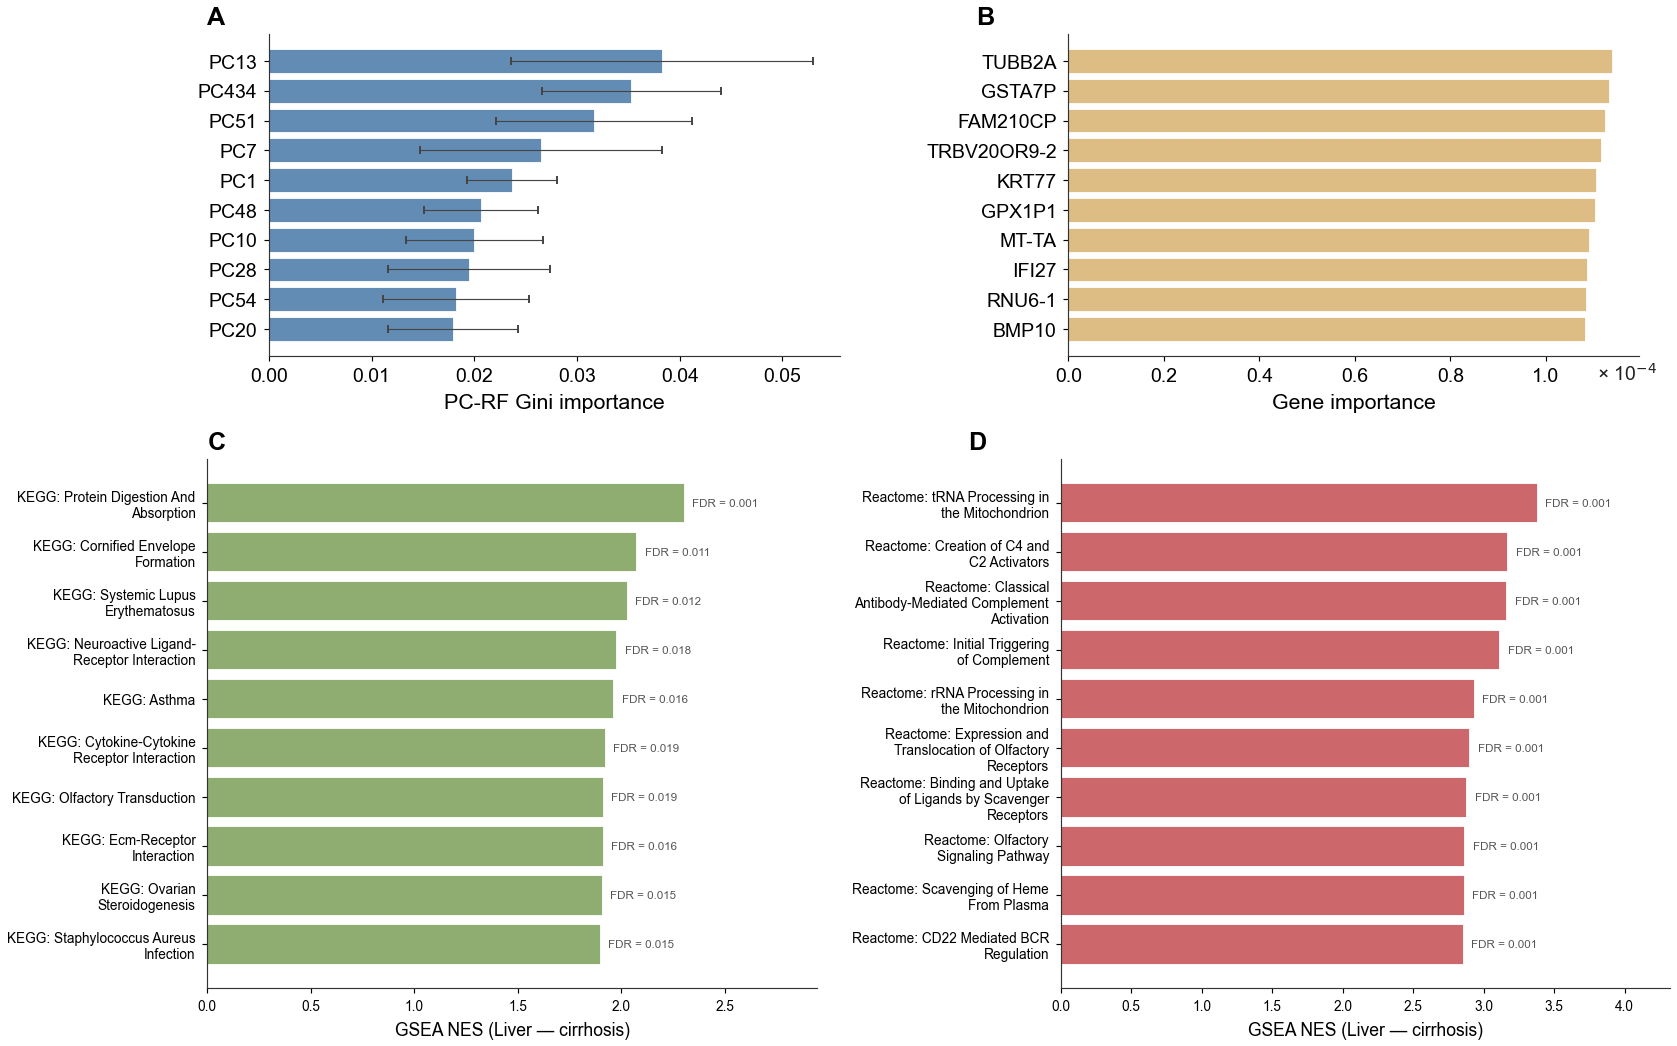

In [4]:
import textwrap

# --- Load Fig 3 data ---------------------------------------------------------
gini_df = pd.read_csv(Config.TABLES_DIR / "liver_cirrhosis_pc_rf_gini.csv")
gene_df = pd.read_csv(Config.TABLES_DIR / "pc_gene_importance_full.csv")
gsea_df = pd.read_csv(Config.TABLES_DIR / "gsea_pathway_enrichment.csv")

# Top 10 PCs (by mean Gini)
top10_pc = gini_df.head(10).iloc[::-1].reset_index(drop=True)

# Top 10 genes for Liver | cirrhosis (named only — drop ENSG-prefixed unannotated)
liv_genes = (gene_df[(gene_df["tissue"] == "Liver") & (gene_df["category"] == "cirrhosis")]
               .sort_values("importance", ascending=False))
liv_named = liv_genes[~liv_genes["gene_name"].str.startswith("ENSG")]
top10_gene = liv_named.head(10).iloc[::-1].reset_index(drop=True)

# Top 10 KEGG pathways (by NES) for Liver | cirrhosis
top10_kegg = (gsea_df[(gsea_df["tissue"] == "Liver")
                      & (gsea_df["category"] == "cirrhosis")
                      & (gsea_df["library"] == "KEGG_2026")]
                .sort_values("nes", ascending=False)
                .head(10)
                .iloc[::-1]
                .reset_index(drop=True))
_kegg_pretty = "KEGG: " + top10_kegg["pathway"].str.title().str.replace(" - ", " — ")
top10_kegg["pathway_pretty"] = _kegg_pretty.apply(
    lambda s: textwrap.fill(s, width=28, break_long_words=False)
)

# Top 10 Reactome pathways (by NES) for Liver | cirrhosis
top10_react = (gsea_df[(gsea_df["tissue"] == "Liver")
                       & (gsea_df["category"] == "cirrhosis")
                       & (gsea_df["library"] == "Reactome_Pathways_2024")]
                 .sort_values("nes", ascending=False)
                 .head(10)
                 .iloc[::-1]
                 .reset_index(drop=True))
_react_pretty = "Reactome: " + top10_react["pathway"].str.replace(" - ", " — ")
top10_react["pathway_pretty"] = _react_pretty.apply(
    lambda s: textwrap.fill(s, width=28, break_long_words=False)
)

# --- Layout -----------------------------------------------------------------
# Two separate GridSpecs so the top row (A|B) and bottom row (C|D) don't
# share column boundaries — each row gets its own positioning to fit its
# content (short labels in A/B, long pathway labels in C/D).
fig = plt.figure(figsize=(11.0, 7.4))

gsTop = fig.add_gridspec(1, 2,
                         left=0.08, right=0.97, top=0.97, bottom=0.66,
                         wspace=0.40)
gsBot = fig.add_gridspec(1, 2,
                         left=0.04, right=0.99, top=0.56, bottom=0.05,
                         wspace=0.40)

# Distinct font sizes per row pair (C/D smaller — long pathway labels need
# more horizontal room, and they're a step "downstream" in the A→B→C/D chain)
LABEL_FS_AB = 11
TICK_FS_AB  = 10
LABEL_FS_CD = 9
TICK_FS_CD  = 7

# ============================================================== A — PC-RF Gini
axA = fig.add_subplot(gsTop[0, 0])
y = np.arange(len(top10_pc))
axA.barh(y, top10_pc["mean_gini"], xerr=top10_pc["std_gini"],
         color=STEEL, alpha=0.85, edgecolor="white", lw=0.5,
         error_kw=dict(lw=0.6, capsize=2, ecolor="#444"))
axA.set_yticks(y)
axA.set_yticklabels([f"PC{int(p)}" for p in top10_pc["pc"]], fontsize=TICK_FS_AB)
axA.tick_params(axis="x", labelsize=TICK_FS_AB)
axA.set_xlabel("PC-RF Gini importance", fontsize=LABEL_FS_AB)
thin_spines(axA)

# ============================================================== B — Gene importance
# Multiply by 1e4 and put the scaling in the axis label so the reader sees
# the units inline rather than as a floating corner annotation.
axB = fig.add_subplot(gsTop[0, 1])
y = np.arange(len(top10_gene))
axB.barh(y, top10_gene["importance"] * 1e4,
         color=GOLD, alpha=0.85, edgecolor="white", lw=0.5)
axB.set_yticks(y)
axB.set_yticklabels(top10_gene["gene_name"], fontsize=TICK_FS_AB)
axB.tick_params(axis="x", labelsize=TICK_FS_AB)
axB.set_xlabel("Gene importance", fontsize=LABEL_FS_AB)
# Place the unit multiplier just past the rightmost tick at tick-label height,
axB.text(1.03, -0.02, "× 10$^{-4}$", transform=axB.transAxes,
         fontsize=TICK_FS_AB, ha="right", va="top", color="#222")
thin_spines(axB)

# ============================================================== C — KEGG NES
# KEGG bars use SAGE (green); Reactome uses CORAL — different colors per
# library so the two panels are visually distinct in print.
axC = fig.add_subplot(gsBot[0, 0])
y = np.arange(len(top10_kegg))
colors_c = [SAGE if f < 0.05 else GRAY for f in top10_kegg["fdr"]]
axC.barh(y, top10_kegg["nes"], color=colors_c, alpha=0.85,
         edgecolor="white", lw=0.5)
for yi, n, f in zip(y, top10_kegg["nes"], top10_kegg["fdr"]):
    axC.text(n + 0.04, yi, f"FDR = {f:.3f}", va="center",
             fontsize=TICK_FS_CD - 1, color="#555")
axC.set_yticks(y)
axC.set_yticklabels(top10_kegg["pathway_pretty"], fontsize=TICK_FS_CD)
axC.tick_params(axis="x", labelsize=TICK_FS_CD)
axC.set_xlabel("GSEA NES (Liver — cirrhosis)", fontsize=LABEL_FS_CD)
axC.set_xlim(0, top10_kegg["nes"].max() * 1.28)
thin_spines(axC)

# ============================================================== D — Reactome NES
axD = fig.add_subplot(gsBot[0, 1])
y = np.arange(len(top10_react))
colors_d = [CORAL if f < 0.05 else GRAY for f in top10_react["fdr"]]
axD.barh(y, top10_react["nes"], color=colors_d, alpha=0.85,
         edgecolor="white", lw=0.5)
for yi, n, f in zip(y, top10_react["nes"], top10_react["fdr"]):
    axD.text(n + 0.06, yi, f"FDR = {f:.3f}", va="center",
             fontsize=TICK_FS_CD - 1, color="#555")
axD.set_yticks(y)
axD.set_yticklabels(top10_react["pathway_pretty"], fontsize=TICK_FS_CD)
axD.tick_params(axis="x", labelsize=TICK_FS_CD)
axD.set_xlabel("GSEA NES (Liver — cirrhosis)", fontsize=LABEL_FS_CD)
axD.set_xlim(0, top10_react["nes"].max() * 1.28)
thin_spines(axD)

# Panel letters
LETTER_X = 0.04
fig.text(LETTER_X, axA.get_position().y1 + 0.005, "A",
         fontsize=13, fontweight="bold", va="bottom", ha="left")
fig.text(axB.get_position().x0 - 0.06, axB.get_position().y1 + 0.005, "B",
         fontsize=13, fontweight="bold", va="bottom", ha="left")
fig.text(LETTER_X, axC.get_position().y1 + 0.005, "C",
         fontsize=13, fontweight="bold", va="bottom", ha="left")
fig.text(axD.get_position().x0 - 0.06, axD.get_position().y1 + 0.005, "D",
         fontsize=13, fontweight="bold", va="bottom", ha="left")

save_fig(fig, "figure_3.pdf"); plt.show()

# Supplementary Figure S1 — Model Comparison Across Screened Pairs

Boxplot + jittered points showing per-pair mean AUC across all screened tissue–pathology pairs for the 6 model variants (LR raw, RF raw, PC-LR, PC-RF, PC-LR + co-variates, PC-RF + co-variates). Liver | cirrhosis is highlighted in red. Companion to Fig 2 panel B, which focuses on Liver | cirrhosis as a single-pair case study.

  saved figure_S1.pdf  (30 KB)


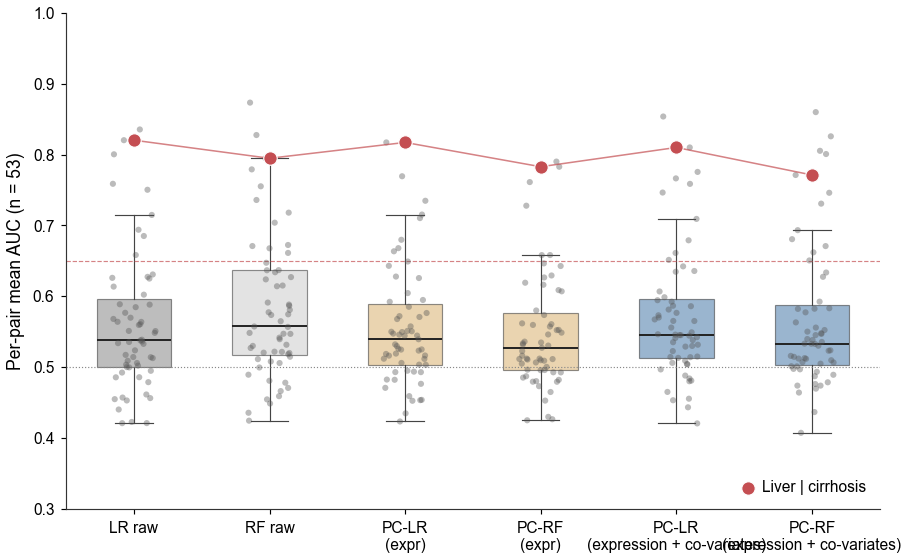

In [5]:
# --- Supplementary S1: 53-pair model boxplot --------------------------------
lr_raw = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv")
rf_raw = pd.read_csv(Config.TABLES_DIR / "cv_results_all_tissue_rf.csv")
pc_rf  = pd.read_csv(Config.TABLES_DIR / "pc_auc_results.csv")
pc_lr_ = pd.read_csv(Config.TABLES_DIR / "pc_lr_results.csv")

merged = (lr_raw[["tissue","category","mean_auc"]]
          .rename(columns={"mean_auc": "lr_raw"})
          .merge(rf_raw[["tissue","category","mean_auc"]]
                 .rename(columns={"mean_auc": "rf_raw"}),
                 on=["tissue","category"])
          .merge(pc_lr_[["tissue","category","auc_pc_lr","auc_pc_lr_conf"]],
                 on=["tissue","category"])
          .merge(pc_rf[["tissue","category","auc_pc","auc_pc_conf"]],
                 on=["tissue","category"]))

fig_s1 = plt.figure(figsize=(7.5, 4.6))
ax = fig_s1.add_subplot(1, 1, 1)

model_cols = ["lr_raw", "rf_raw", "auc_pc_lr", "auc_pc", "auc_pc_lr_conf", "auc_pc_conf"]
model_labels = ["LR raw", "RF raw", "PC-LR\n(expr)", "PC-RF\n(expr)",
                "PC-LR\n(expression + co-variates)", "PC-RF\n(expression + co-variates)"]
box_palette = [GRAY, GRAY_LT, GOLD, GOLD, STEEL, STEEL]
positions = np.arange(len(model_cols))

box_data = [merged[c].values for c in model_cols]
bp = ax.boxplot(box_data, positions=positions, widths=0.55, patch_artist=True,
                showfliers=False, medianprops=dict(color="#222", lw=1.0),
                whiskerprops=dict(color="#444", lw=0.6),
                capprops=dict(color="#444", lw=0.6),
                boxprops=dict(lw=0.6))
for box, color in zip(bp["boxes"], box_palette):
    box.set_facecolor(color); box.set_alpha(0.55); box.set_edgecolor("#333")

rng = np.random.default_rng(0)
for i, col in enumerate(model_cols):
    vals = merged[col].values
    jitter = rng.uniform(-0.16, 0.16, len(vals))
    ax.scatter(positions[i] + jitter, vals, s=10, color="#555", alpha=0.4,
               edgecolor="none", zorder=3)

liv = merged[(merged.tissue == "Liver") & (merged.category == "cirrhosis")].iloc[0]
liv_aucs = [liv[c] for c in model_cols]
ax.plot(positions, liv_aucs, color=CORAL, lw=0.8, zorder=4, alpha=0.7)
ax.scatter(positions, liv_aucs, s=48, color=CORAL, edgecolor="white",
           linewidth=0.6, zorder=5, label="Liver | cirrhosis")

ax.axhline(0.5, color=GRAY, ls=":", lw=0.6)
ax.axhline(0.65, color=CORAL, ls="--", lw=0.6, alpha=0.7)
ax.set_xticks(positions); ax.set_xticklabels(model_labels, fontsize=8)
ax.tick_params(axis="y", labelsize=8)
ax.set_ylabel("Per-pair mean AUC (n = 53)", fontsize=9)
ax.set_ylim(0.30, 1.0)
ax.legend(loc="lower right", fontsize=8, frameon=False, handletextpad=0.3)
thin_spines(ax)

save_fig(fig_s1, "figure_S1.pdf"); plt.show()